In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение пакета math
import math

In [ ]:
# Ячейка № 2

# задание функции, возвращающую
# единичную реализацию зависимости
# числа частиц, находящихся в левой
# половине ящика, от времени
def Particle_at_the_left(N_Particle, N_Step):
    # N_Particle - число частиц в левой
    #              половине ящика
    # N_step - длина единичной реализации

    # инициализация массива, используемого для
    # хранения <<мгновенных>> значений зависимости
    # <<число частиц в левой половине ящика от времени>>
    Left_N = np.zeros(N_Step + 1)

    # размещение нулевом элементе массива Left_N
    # числа частиц, находящихся в левой половине ящика
    # в момент времени t = 0
    Left_N[0] = N_Particle

    # вычисление <<мгновенных>> значений зависимости
    # <<число частиц в левой половине ящика от времени>>
    for i in range(1, N_Step + 1):
        Prob = Left_N[i - 1] / N_Particle
        if Prob >= random.uniform(0, 1):
            Left_N[i] = Left_N[i - 1] - 1
        else:
            Left_N[i] = Left_N[i - 1] + 1

    return Left_N

In [3]:
# Ячейка № 3

# задание функции, возвращающей
# ансамбль <<мгновенных>> значений зависимости
# <<число частиц в левой половине ящика от времени>>
def Ensamble(N_Trial, N_Particle, N_Step):
    # N_Trial - число независимых реализаций
    # N_Particle - число частиц в левой
    #              половине ящика
    # N_step - длина единичной реализации

    # инициализация массива, используемого
    # для размещения ансамбля реализаций
    z = np.zeros([N_Step + 1, N_Trial])
    for i in range(N_Trial):
        Z = Particle_at_the_left(N_Particle, N_Step)
        z[:, i] = Z
    return z

In [4]:
# Ячейка № 4

# задание функции, возвращающей
# вероятность появления равновесного
# макросостояния статистической системы
def Prob(B, N_Particle, N_Step, N_Trial, Tau):
    # B - матрица, возвращенная функцией Ensamble
    # N_Particle - число частиц в левой
    #              половине ящика
    # N_step - длина единичной реализации
    # N_Trial - число независимых реализаций

    N = np.zeros(N_Particle)
    for k in range(N_Particle):
        n = 0
        for j in range(N_Trial):
            for i in range(Tau, N_Step):
                if B[i, j] == k:
                    n = n + 1
        N[k] = n
    Nf = sum(N)
    return N / Nf

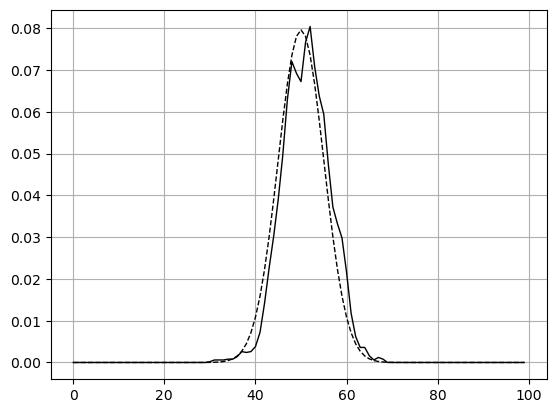

In [5]:
# Ячейка № 5

# задание функций, используемых
# для моделирования процесса релаксации
# статистической системы
# к равновесному состоянию

# инициализация генератора случайных чисел
random.seed()

# задание числа частиц
# моделируемой системы
N_Particle = 100

#  задание длины единичной реализации
N_Step = 200

# задание числа независимых испытаний
N_Trial = 100

# вычисление ансамбля <<мгновенных>>
# значений зависимости <<число частиц в
# левой половине ящика от времени>>
E = Ensamble(N_Trial, N_Particle, N_Step)

# задание момента времени,
# начиная с которого состояние
# статистической системы
# считается равновесной
Tau = 150

# вычисление теоретической вероятности
# появления данного макросостояния
P_Theory = np.zeros(N_Particle)
for i in range(N_Particle):
    P_Theory[i] = (
        math.factorial(N_Particle)
        / (math.factorial(i) * math.factorial(N_Particle - i))
        / 2**N_Particle
    )

# вычисление эмпирической вероятности
# появления данного макросостояния
A = Prob(E, N_Particle, N_Step, N_Trial, Tau)

# визуализация эмпирической и теоретических вероятностей
plt.plot(P_Theory, "--k", lw=1)
plt.plot(A, "-k", lw=1)
plt.grid(True)

plt.show()